# Notebook 18 - El certificado computable

Sesión del 9 de julio de 2026. Cinco actos: una corrección al Gibbs
(demostrada en vivo), la primera cota penalizada del problema, el mapa con
garantías, la dirección propuesta, y una demo. Cada acto cierra con una
pregunta para discutir. Ningún número está escrito a mano.

In [1]:
import os, sys
sys.path.insert(0, os.path.dirname(os.path.dirname(os.path.abspath(''))))
import random, math, itertools
import pandas as pd
import matplotlib.pyplot as plt

import augmented
ROOT = os.path.dirname(os.path.dirname(os.path.abspath(augmented.__file__)))
DATA = os.path.join(ROOT, 'augmented', 'data')
FIGS = os.path.join(ROOT, 'augmented', 'figures')

AZUL, GRIS, AMBAR, TINTA = '#2563eb', '#6b7280', '#d97706', '#374151'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True,
                     'grid.alpha': 0.25, 'grid.linewidth': 0.5,
                     'font.size': 10})
print('repo:', ROOT)

repo: /Users/hectorbecerrilvillamil/Desktop/GroupCounting/group-count-dynamic


## 1. El Gibbs necesitaba una segunda corrección

Una cadena MCMC necesita dos cosas distintas: llegar a todos los estados
(irreducibilidad) y visitarlos con las frecuencias correctas (equilibrio
detallado). El arreglo de junio dio la primera. Faltaba la segunda.

El porqué, en el contraejemplo (tests $\{0,1,2\}=1$ y $\{2,3,4\}=1$): para
salir del estado $A=(0,0,1,0,0)$ hay que elegir un sustituto en cada test —
dos opciones y dos opciones. Para regresar no se elige nada. **Regresar a
$A$ es 4 veces más probable que salir.** La aceptación ignoraba esa
asimetría (le faltaba el factor de Hastings), así que la cadena pasaba
demasiado tiempo en $A$. Abajo: la misma propuesta, con y sin la corrección,
contra la posterior exacta.

In [2]:
from augmented.core import mask_from_indices
from augmented.bayesian import (bayesian_update_by_counting,
                                _propose_alternating_move, _find_valid_state)

p = [0.1, 0.3, 0.5, 0.7, 0.9]
n = 5
tests = [([0, 1, 2], 1), ([2, 3, 4], 1)]
history = tuple((mask_from_indices(m), r) for m, r in tests)
exact = bayesian_update_by_counting(p, history, n)

# la fibra: los perfiles consistentes con ambos conteos
fiber = [z for z in itertools.product((0, 1), repeat=n)
         if all(sum(z[a] for a in m) == r for m, r in tests)]
w = [math.prod(p[i] if z[i] else 1 - p[i] for i in range(n)) for z in fiber]
pi_exact = [x / sum(w) for x in w]

comp = list(range(n))
agent_tests = {a: [] for a in comp}
for ti, (members, r) in enumerate(tests):
    for a in members:
        agent_tests[a].append(ti)

def run_chain(use_hastings, iters=60000, burn=5000, seed=0):
    rng = random.Random(seed)
    remaining = [(mask_from_indices(m), r) for m, r in tests]
    state = _find_valid_state(remaining, comp, p, rng)
    visits = {z: 0 for z in fiber}
    trace_x, trace_y = [], []
    acc2 = draws = 0
    for it in range(iters):
        prop = _propose_alternating_move(comp, tests, agent_tests, state,
                                         rng, max_steps=42)
        if prop is not None:
            move, log_corr = prop
            log_ratio = log_corr if use_hastings else 0.0
            ok = True
            for a, nv in move.items():
                ov = state[a]
                if nv == ov:
                    continue
                num = p[a] if nv == 1 else 1.0 - p[a]
                den = p[a] if ov == 1 else 1.0 - p[a]
                if num <= 0:
                    ok = False; break
                log_ratio += math.log(num) - math.log(den)
            if ok and (log_ratio >= 0 or rng.random() < math.exp(log_ratio)):
                state.update(move)
        if it >= burn:
            z = tuple(state[a] for a in comp)
            visits[z] += 1
            acc2 += state[2]
            draws += 1
            if draws % 250 == 0:
                trace_x.append(draws)
                trace_y.append(acc2 / draws)
    freqs = [visits[z] / draws for z in fiber]
    return freqs, (trace_x, trace_y)

freq_bug, trace_bug = run_chain(use_hastings=False)
freq_fix, trace_fix = run_chain(use_hastings=True)
labels = [''.join(map(str, z)) for z in fiber]
print('fibra de', len(fiber), 'estados:', labels)

fibra de 5 estados: ['00100', '01001', '01010', '10001', '10010']


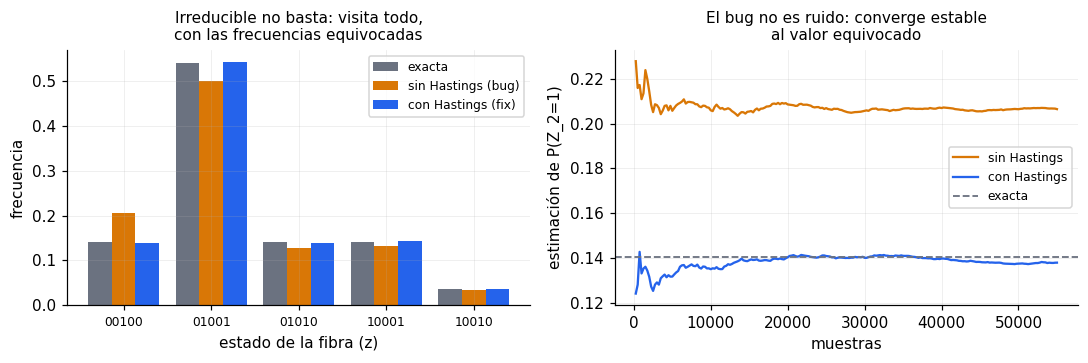

max error sobre la fibra: sin Hastings 0.066 | con Hastings 0.003


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 3.4))

x = range(len(fiber))
bw = 0.27
ax1.bar([i - bw for i in x], pi_exact, bw, color=GRIS, label='exacta')
ax1.bar(list(x), freq_bug, bw, color=AMBAR, label='sin Hastings (bug)')
ax1.bar([i + bw for i in x], freq_fix, bw, color=AZUL, label='con Hastings (fix)')
ax1.set_xticks(list(x)); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_xlabel('estado de la fibra (z)'); ax1.set_ylabel('frecuencia')
ax1.set_title('Irreducible no basta: visita todo,\ncon las frecuencias equivocadas', fontsize=10)
ax1.legend(fontsize=8)

ax2.plot(*trace_bug, color=AMBAR, label='sin Hastings')
ax2.plot(*trace_fix, color=AZUL, label='con Hastings')
ax2.axhline(exact[2], color=GRIS, ls='--', lw=1.2, label='exacta')
ax2.set_xlabel('muestras'); ax2.set_ylabel('estimación de P(Z_2=1)')
ax2.set_title('El bug no es ruido: converge estable\nal valor equivocado', fontsize=10)
ax2.legend(fontsize=8)
fig.tight_layout(); plt.show()

err_bug = max(abs(a - b) for a, b in zip(freq_bug, pi_exact))
err_fix = max(abs(a - b) for a, b in zip(freq_fix, pi_exact))
print(f'max error sobre la fibra: sin Hastings {err_bug:.3f} | con Hastings {err_fix:.3f}')

Izquierda: la cadena con bug visita los cinco estados (es irreducible) pero
sobrecarga $00100$, justo el 4:1. Derecha: lo peligroso — la curva ámbar no
oscila, se instala estable en el número equivocado. Más iteraciones no
arreglan un sesgo.

La prueba formal fue más fuerte que esta demo: matriz de transición exacta
de la cadena (enumerando el generador) — TV 0.067 antes, 0.000000 después,
en cinco topologías. Nada con $n \le 14$ tocó esta rama; la escalada a
$n=30$–$50$ ahora pisa firme. Las distancias van en TV, como pediste.

> **Para discutir.** Con la cadena ya válida, ¿el grado $K$ acotado descarta
> cuellos de botella en la fibra y da mixing polinomial?

## 2. La primera cota penalizada

El óptimo es incalculable más allá de $n=14$. Para certificar una política
hay que acotarlo por arriba:

$$\text{greedy} \;\le\; \text{OPT} \;\le\; U_{pen} \;\le\; U_{PI}$$

$U_{PI}$ es lo que lograría un planificador que conoce la verdad —quién está
enfermo— antes de decidir. Como lo ve todo, su valor es un techo de lo que
cualquiera puede lograr; pero un techo flojo, porque conocer la verdad es una
ventaja enorme. $U_{pen}$ hace la comparación justa: deja que ese planificador
siga viendo la verdad, pero le COBRA por cada paso en que verla le ayudó. La
multa se diseña para que a un jugador honesto —que no ve la verdad— le salga
gratis en promedio, y al que sí la ve le cueste exactamente la ventaja que
sacó. Por eso $U_{pen}$ sigue siendo techo (OPT $\le U_{pen}$) pero más bajo
que $U_{PI}$: una cota más apretada. El teorema (Brown–Smith–Sun): cualquier
multa así construida da cota válida; elegirla bien solo la aprieta más. El
certificado es greedy$/U_{pen}$ — y nadie había traído esta técnica aquí.

Falta nombrar la pieza que el resto de la sesión mueve. La multa no se elige a
mano: se construye a partir de una función $\hat V$. Una $\hat V$ es una corazonada
del valor-a-futuro — dado lo observado hasta ahora, cuánta utilidad espera uno
todavía cobrar con los tests que quedan. La penalización de cada paso es cuánto
cambia esa corazonada al ver el resultado del test. La $\hat V$ es la única perilla
del método: el teorema garantiza que cualquiera da cota válida, y una mejor solo la
aprieta. La $\hat V$ ideal es el valor-a-futuro exacto —con ella la cota tocaría el
óptimo—, pero calcularlo es resolver el problema; por eso la investigación busca una
$\hat V$ barata que se le acerque. La de este ejemplo, $umax$, es la más simple que
sirve: supone que al final se acredita a todos los que aún podrían estar limpios.

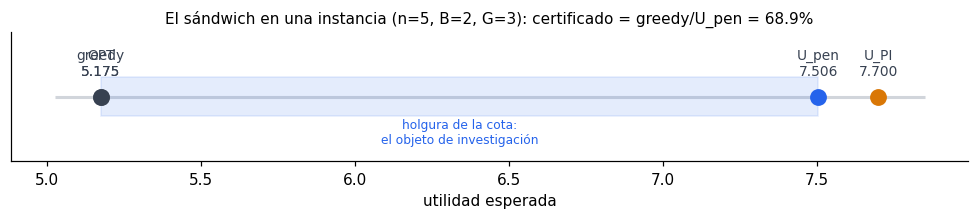

In [4]:
from augmented.solver import solve_optimal_dapts
from augmented.greedy import greedy_myopic_expected_utility
from augmented.certificates import u_pi_exact, u_pen_exact

p_i = [0.3, 0.4, 0.5, 0.25, 0.6]
u_i = [3.0, 1.0, 2.0, 4.0, 2.5]
B, G = 2, 3
opt, _ = solve_optimal_dapts(p_i, u_i, B, G)
grd = greedy_myopic_expected_utility(p_i, u_i, B, G)
upi = u_pi_exact(p_i, u_i, B, G)
upen = u_pen_exact(p_i, u_i, B, G, v_hat='umax')
assert grd <= opt + 1e-9 <= upen + 2e-9 and upen <= upi + 1e-9

fig, ax = plt.subplots(figsize=(9, 2.1))
pts = [(grd, 'greedy', GRIS), (opt, 'OPT', TINTA),
       (upen, 'U_pen', AZUL), (upi, 'U_PI', AMBAR)]
ax.axhspan(-0.1, 0.1, xmin=0, xmax=1, color='none')
ax.hlines(0, grd - 0.15, upi + 0.15, color='#d1d5db', lw=2, zorder=1)
ax.axvspan(opt, upen, ymin=0.35, ymax=0.65, color=AZUL, alpha=0.12)
for v, name, c in pts:
    ax.plot([v], [0], 'o', ms=10, color=c, zorder=3)
    ax.annotate(f'{name}\n{v:.3f}', (v, 0), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=9, color=TINTA)
ax.annotate('holgura de la cota:\nel objeto de investigación',
            ((opt + upen) / 2, 0), textcoords='offset points',
            xytext=(0, -30), ha='center', fontsize=8, color=AZUL)
ax.set_yticks([]); ax.set_xlabel('utilidad esperada')
ax.set_title(f'El sándwich en una instancia (n=5, B=2, G=3): '
             f'certificado = greedy/U_pen = {grd/upen:.1%}', fontsize=10)
ax.grid(False)
fig.tight_layout(); plt.show()

¿Por qué $U_{PI}$ es floja? El que conoce la verdad es demasiado fuerte: con
presupuesto suficiente limpia a casi todos y la cota se pega a $U^{\max}$:

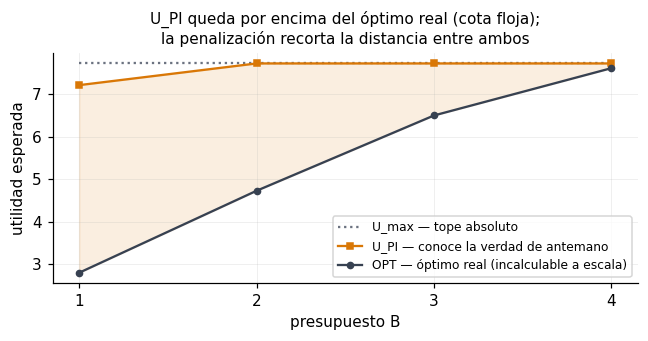

In [5]:
from augmented.baselines import u_max

Bs = [1, 2, 3, 4]
curves = {'OPT': [], 'U_PI': [], 'U_max': []}
for Bx in Bs:
    o = up = um = 0.0
    K = 4
    for s in range(K):
        rng = random.Random(100 + s)
        pp = [rng.uniform(0.25, 0.6) for _ in range(5)]
        uu = [rng.uniform(1.0, 5.0) for _ in range(5)]
        o += solve_optimal_dapts(pp, uu, Bx, 3)[0] / K
        up += u_pi_exact(pp, uu, Bx, 3) / K
        um += u_max(pp, uu) / K
    curves['OPT'].append(o); curves['U_PI'].append(up); curves['U_max'].append(um)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(Bs, curves['U_max'], ls=':', color=GRIS, label='U_max — tope absoluto')
ax.plot(Bs, curves['U_PI'], marker='s', ms=4, color=AMBAR, label='U_PI — conoce la verdad de antemano')
ax.plot(Bs, curves['OPT'], marker='o', ms=4, color=TINTA, label='OPT — óptimo real (incalculable a escala)')
ax.fill_between(Bs, curves['OPT'], curves['U_PI'], color=AMBAR, alpha=0.12)
ax.set_xticks(Bs); ax.set_xlabel('presupuesto B')
ax.set_ylabel('utilidad esperada')
ax.set_title('U_PI queda por encima del óptimo real (cota floja);\nla penalización recorta la distancia entre ambos', fontsize=10)
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

El resultado sobre 106 instancias (cero violaciones de $U_{pen} \ge$ OPT):

In [ ]:
cert = pd.read_csv(os.path.join(DATA, 'certificates_small_n.csv'))
tabla = (cert.groupby(['n', 'B', 'G'])[['true_ratio', 'cert_pi', 'cert_pen']]
             .mean())
cfgs = [f"n={a} B={b} G={g}" for a, b, g in tabla.index]

fig, ax = plt.subplots(figsize=(8, 3.4))
y = range(len(cfgs))[::-1]
for yi, (_, row) in zip(y, tabla.iterrows()):
    ax.hlines(yi, row['cert_pi'], row['cert_pen'], color=AZUL, lw=3, alpha=0.8)
    ax.plot([row['cert_pi']], [yi], 'o', color=AMBAR, ms=7, zorder=3)
    ax.plot([row['cert_pen']], [yi], 'o', color=AZUL, ms=7, zorder=3)
    ax.plot([row['true_ratio']], [yi], 'D', color=GRIS, ms=6, zorder=3)
ax.set_yticks(list(y)); ax.set_yticklabels(cfgs, fontsize=9)
ax.set_xlabel('fracción del óptimo')
ax.set_xlim(0.55, 1.02)
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], marker='o', color=AMBAR, ls='', label='certificado U_PI'),
    Line2D([], [], marker='o', color=AZUL, ls='', label='certificado U_pen'),
    Line2D([], [], marker='D', color=GRIS, ls='', label='greedy/OPT (real)')],
    fontsize=8, loc='lower right')
ax.set_title('Cuánto aprieta la penalización sobre cada configuración,\ny la distancia que aún falta hasta el valor real', fontsize=10)
fig.tight_layout(); plt.show()
print(tabla.round(3))

Tres lecturas:

1. El greedy real está en 0.93–0.99 del óptimo; lo demostrable ronda 0.7.
   **El cuello de botella es la demostración, no el algoritmo.**
2. La penalización funciona: +4 a +5 puntos, primera vez que algo aprieta la
   hindsight en este problema.
3. El apriete vive en $B=2$ y muere en $B=3$ — el mismo patrón que la ley
   del lookahead (99% → 40% → 16%). **La multa miope es anticipación de un
   paso.**

Un fracaso instructivo: la $\hat V$ sofisticada (el valor a futuro del
greedy) certifica *peor* que la simple. Usa marginales como si fueran
independientes, y el que conoce la verdad explota ese sesgo. El independence
gap atacando al certificado.

> **Para discutir.** ¿Existe una $\hat V$ con profundidad $d(B)$ — insesgada
> y con alcance creciente en el horizonte — cuyo problema interno se
> descomponga? Sería el primer certificado apretado en $n=50$.

## 3. El mapa con garantías

Tus tres perillas en un solo objeto. En cada punto $(B, \text{cap})$: la
fracción real del valor (solo computable en $n$ chico) y la certificable a
cualquier escala. La banda entre ambas es el programa de investigación.

In [ ]:
cmap = pd.read_csv(os.path.join(DATA, 'certified_map.csv'))
resumen = (cmap.groupby(['B', 'cap'])[['real_frac', 'cert_frac']]
               .mean().round(3).unstack('cap'))
print(resumen)
from IPython.display import Image, display
display(Image(filename=os.path.join(FIGS, 'certified_map.png')))

Dos datos: la fracción certificada crece con el horizonte (0.58 → 0.85), y
en $B=3$ el canal de tres niveles certifica lo mismo que el conteo completo
(0.85 vs 0.79 del binario). La versión certificada del 84.5%: **el canal
barato no pierde nada demostrable**.

> **Para discutir.** Falta el panel de $K$: con traslape acotado, ¿la banda
> se cierra o se abre?

## 4. La dirección: el cuarto eje

La escalera completa de una instancia, de la política más simple a la cota
más floja. Cada hueco es una línea de investigación.

In [ ]:
from augmented.baselines import u_single
from augmented.classical_solver import solve_classical_dynamic

# instancia elegida para que TODOS los peldaños se separen a la vista
# (B*G = 4 < n = 5: sin saturación de la hindsight)
rngL = random.Random(4)
p_L = [rngL.uniform(0.25, 0.65) for _ in range(5)]
u_L = [rngL.uniform(1.0, 5.0) for _ in range(5)]
BL, GL = 2, 2

vals = {}
vals['U_single'] = u_single(p_L, u_L, BL)[0]
vals['U_D (binario)'] = solve_classical_dynamic(p_L, u_L, BL, GL)[0]
vals['greedy'] = greedy_myopic_expected_utility(p_L, u_L, BL, GL)
vals['OPT (=U_DA)'] = solve_optimal_dapts(p_L, u_L, BL, GL)[0]
vals['U_pen'] = u_pen_exact(p_L, u_L, BL, GL, v_hat='umax')
vals['U_PI'] = u_pi_exact(p_L, u_L, BL, GL)
vals['U_max'] = u_max(p_L, u_L)
names = list(vals); xs = range(len(names))
colors = [GRIS, GRIS, GRIS, TINTA, AZUL, AMBAR, '#d1d5db']

fig, ax = plt.subplots(figsize=(9.5, 4.0))
ax.bar(xs, [vals[k] for k in names], color=colors, width=0.62)
for i, k in enumerate(names):
    ax.annotate(f'{vals[k]:.2f}', (i, vals[k]), ha='center',
                textcoords='offset points', xytext=(0, 4), fontsize=9,
                color=TINTA)
def brace(i, j, text, y):
    ax.annotate('', xy=(j, y), xytext=(i, y),
                arrowprops=dict(arrowstyle='<->', color=TINTA, lw=1))
    ax.annotate(text, ((i + j) / 2, y), textcoords='offset points',
                xytext=(0, 5), ha='center', fontsize=8, color=TINTA,
                bbox=dict(fc='white', ec='none', alpha=0.85, pad=1.5),
                zorder=5)
top = vals['U_max']
brace(1, 3, 'valor del conteo (D2)', vals['OPT (=U_DA)'] + 0.9)
brace(3, 4, 'holgura de la cota (D3)', vals['U_pen'] + 0.8)
brace(2, 3, 'miopía (lookahead d(B))', vals['U_single'] - 1.6)
ax.set_ylim(0, top * 1.16)
ax.set_xticks(list(xs)); ax.set_xticklabels(names, fontsize=9)
ax.set_ylabel('utilidad esperada')
ax.set_title('La escalera completa (n=5, B=2, G=2): de la política más simple\n'
             'a la cota más floja; cada hueco entre peldaños es una línea de investigación', fontsize=10)
fig.tight_layout(); plt.show()

Tu mapa dice cuándo la información vale. La dirección propia agrega el eje
que falta: **cuánto de ese valor se puede reclamar y certificar con cómputo
finito**. Con ese lente, D3 es el certificado; D1 dice cuándo su inferencia
es computable; D2 es el certificado aplicado al canal; y el horizonte
reaparece en el patrón del apriete.

> **Para discutir.** ¿Es este el cuarto eje correcto? ¿Cuál hueco de la
> escalera merece el teorema primero?

## 5. En la recámara: el motor como producto

Evaluación de flotas de agentes de IA: cada corrida toca varios componentes
(un pool) y reporta cuántas fallas, no cuáles (el conteo). Es el problema de
la tesis sin traducir nada:

In [ ]:
from augmented.demo_fleet_certification import (build_fleet, selector,
                                                random_selector, mc_value,
                                                B as FB, G as FG)
from augmented.certificates import u_pi_mc

rng = random.Random(7)
names50, fp, fu = build_fleet(rng)
mean_g, se_g = mc_value(fp, fu, selector, 80, seed=100)
mean_r, se_r = mc_value(fp, fu, random_selector(random.Random(3)), 80, seed=100)
upi50 = u_pi_mc(fp, fu, FB, FG, num_samples=60000, seed=0)

fig, ax = plt.subplots(figsize=(5.5, 3.2))
bars = ax.bar(['muestreo aleatorio', 'motor DAPTS'], [mean_r, mean_g],
              color=[GRIS, AZUL], width=0.5,
              yerr=[se_r, se_g], capsize=4)
ax.axhline(upi50, color=AMBAR, ls='--', lw=1.4)
ax.annotate('U_PI: nadie puede más que esto', (0.02, upi50),
            textcoords='offset points', xytext=(0, 5), fontsize=8, color=AMBAR)
for b, v in zip(bars, [mean_r, mean_g]):
    ax.annotate(f'{v/upi50:.0%} certificado', (b.get_x() + b.get_width()/2, v),
                ha='center', textcoords='offset points', xytext=(0, 6),
                fontsize=9, color=TINTA)
ax.set_ylabel('valor esperado (flota n=50, B=10, G=5)')
ax.set_title('Mismo presupuesto de evals, con y sin matemáticas', fontsize=10)
fig.tight_layout(); plt.show()

Mismo presupuesto: el motor certifica ~77% del óptimo; el muestreo aleatorio,
~46%. Con la cota penalizada escalable ese número sube sin cambiar el motor.
El certificado es a la vez el teorema y el producto.

## 6. Postdata: un agente cerró el hueco de B=3

La pregunta 1 (§7) ya tiene una primera respuesta, y no la escribí yo. Monté
un bucle de investigación autónomo (`dapts-autoresearch`) cuya única libertad
es editar $\hat V$ —esa corazonada del valor-a-futuro del acto 2—; el teorema
de Brown–Smith–Sun es la jaula: cualquier $\hat V$ da cota válida, así que el
agente no puede romper la corrección aunque quiera. Corrió toda la noche y encontró una $\hat V$ **escalable** que
aprieta en B=3, donde $umax$ era plano. La idea: en vez de calcular el
valor-a-futuro exacto (que enumera todos los perfiles de infección posibles y
no escala), lo estima mirando un solo paso adelante, pero **respetando la
correlación dentro de cada grupo de personas que aparecen juntas en los
tests**. Esa correlación se calcula grupo por grupo, que es barato, sin tocar
el conjunto global. Es la $\hat V$ con profundidad $d(B)$ sobre marginales que
buscábamos.

In [ ]:
CFGS = [(4, 2, 2, 3), (5, 2, 3, 3), (5, 3, 3, 2), (6, 2, 3, 2), (6, 3, 3, 2)]

def tighten_by_B(vh):
    acc = {2: [], 3: []}
    for n, B, G, K in CFGS:
        for s in range(K):
            r = random.Random(42 + 1000*n + 100*B + 10*G + s)
            p = [r.uniform(0.05, 0.6) for _ in range(n)]
            u = [r.uniform(1.0, 5.0) for _ in range(n)]
            g = greedy_myopic_expected_utility(p, u, B, G)
            upi = u_pi_exact(p, u, B, G)
            upen = u_pen_exact(p, u, B, G, v_hat=vh)
            assert upen >= greedy_myopic_expected_utility(p,u,B,G)*0  # válida
            acc[B].append(g/upen - g/upi)
    return {B: sum(v)/len(v) for B, v in acc.items()}

t_umax = tighten_by_B('umax')
t_res = tighten_by_B('research')   # la V-hat que encontró el agente

fig, ax = plt.subplots(figsize=(6, 3.4))
xs = [0, 1]; bw = 0.36
ax.bar([x - bw/2 for x in xs], [t_umax[2], t_umax[3]], bw,
       color=GRIS, label='umax (lo de ayer)')
ax.bar([x + bw/2 for x in xs], [t_res[2], t_res[3]], bw,
       color=AZUL, label='research (el agente)')
ax.axhline(0, color=TINTA, lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels(['B = 2', 'B = 3'])
ax.set_ylabel('apriete del certificado')
ax.set_title('El agente aprieta donde umax era plano (B=3),\ny la V-hat pasa la prueba de escalabilidad', fontsize=10)
ax.legend(fontsize=8)
for x, v in zip([xs[1] - bw/2, xs[1] + bw/2], [t_umax[3], t_res[3]]):
    ax.annotate(f'{v:+.3f}', (x, v), ha='center', textcoords='offset points',
                xytext=(0, 3 if v >= 0 else -12), fontsize=9, color=TINTA)
fig.tight_layout(); plt.show()
print(f"tighten_b3:  umax {t_umax[3]:+.4f}   research {t_res[3]:+.4f}")

El detalle que lo hace un resultado y no un truco: la $\hat V$ ganadora pasa
la **prueba de escalabilidad** (se la llama en $n=32$ con tope de tiempo; una
$\hat V$ que enumere $2^n$ truena ahí). Anteanoche el agente había encontrado
la versión tramposa — el value-to-go exacto, apretada pero circular porque
resuelve el problema; ayer endurecí el benchmark para prohibirla, y esta
noche encontró la versión honesta. La coincidencia estructural que nos
intrigaba (apriete y lookahead obedecen la misma ley de horizonte) resultó
ser constructiva: la profundidad correlacionada es exactamente lo que faltaba.

> **Para discutir.** Esto vale en $n\le 6$, donde las componentes son chicas.
> A $n=50$ con traslape fuerte las componentes crecen y el lookahead por
> componentes pasa a ser aproximación. ¿Sobrevive el apriete? Es la pieza que
> el certificado a escala necesita — y ahora hay una $\hat V$ concreta que
> probar.

## 7. Tres preguntas para trabajar juntos

1. **La $\hat V$ con profundidad $d(B)$** — con una primera respuesta ya (§6):
   ¿el lookahead correlacionado por componentes se sostiene a $n=50$ cuando
   las componentes no caben en el cap?
2. **El conteo con ruido.** Si el test reporta $r$ con error (cycle threshold, grader
   LLM), ¿sobrevive el resultado del canal barato? Cuarta perilla del mapa.
3. **Mixing del Gibbs como función de $K$.** La cadena ya es válida; con
   grado acotado, ¿el mixing es polinomial? El puente entre D1 y el
   certificado.